# A-priori SAE Firing-Structure Router — demo

**Artifact:** *A-priori SAE firing-structure router as a screening heuristic with measured error.*

Single SAE latents are unreliable units of analysis (feature absorption, feature splitting, non-atomicity). This method asks a cheap, **label-free** question from a single forward pass of the Gemma-Scope L12 / 16k JumpReLU SAE over `gemma-2-2b`: *should a concept be handled by one raw latent, or by a small grouped unit?*

It reads two firing-structure signals per concept and combines them into a screening rule:

> predict **ABSORPTION** regime iff `(firing-Jaccard < tau_J)` **AND** `(parent recall-hole > tau_h)`, else **CO-FIRING**.

- **Absorption** → the label-free grouped unit (parent anchor + firing-disjoint hole-covering absorbers) beats the best single raw SAE latent.
- **Co-firing** → a single specialist latent already wins; grouping cannot help.

The contribution is *methodological honesty*: thresholds are FIT only on a **derivation** set, then the **frozen** rule is applied to a truly **prospective** set whose hit-rate + Wilson CI is the **measured error** of the screen.

### What this notebook runs

The GPU forward pass (the part that needs `gemma-2-2b` + the SAE) produced one **router card** per concept — the firing-Jaccard, the recall-hole, and the held-out downstream AUCs of the grouped unit vs three baselines. This notebook **loads those precomputed cards** and reproduces the label-free **router analysis** on CPU: freeze the combined rule, run the single-signal ablations and leave-one-out, and report the prospective hit-rate with Wilson CIs.

The loaded data is the 6-concept `--smoke` subset that was actually emitted (a co-tenant job held the shared GPU continuously for >2.5h, blocking the full 24-concept pass). The analysis code below is copied verbatim from `method.py` and reproduces the shipped `method_out.json` exactly.

In [1]:
# Install dependencies (Colab-safe).
# The router ANALYSIS layer demoed here needs only numpy / pandas / matplotlib -- all pre-installed on
# Colab. The original method.py additionally uses torch + transformers + sae_lens for the GPU forward
# pass that PRODUCES the per-concept firing-structure cards; that stage is NOT re-run here (it needs a
# GPU + gemma-2-2b + the Gemma-Scope SAE). We load its precomputed output instead.
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab; installed locally to match Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- analysis-layer imports (from the original method.py) ---
import json, math
import numpy as np
# --- extra imports for the notebook (data loading + visualization) ---
import os, urllib.request
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load mini_demo_data.json from GitHub (works on Colab), with a local-file fallback (works now).
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-4/experiment-5/demo/mini_demo_data.json"

def load_data():
    try:
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
concepts = data["concepts"]
meta = data["metadata"]

# method.py always carries the two firing signals as floats (NaN when a concept has no eligible
# sub-context); JSON stores those NaNs as null, so normalize null -> NaN to match the original types.
for c in concepts:
    if c["jaccard_median"] is None:  c["jaccard_median"] = float("nan")
    if c["recall_hole_max"] is None: c["recall_hole_max"] = float("nan")

print("loaded", len(concepts), "per-concept router cards (scale =", meta["scale"], ")")
print("SAE    :", meta["sae_release"], meta["sae_id"])
print("model  :", meta["model"], "| hook:", meta["hook"])
print("seed   :", meta["seed"], "| firing convention:", meta["firing_convention"])
print("concepts:")
for c in concepts:
    print("  -", c["concept"], "(", c["role"], ")")

loaded 6 per-concept router cards (scale = smoke )
SAE    : google/gemma-scope-2b-pt-res layer_12/width_16k/average_l0_82/params.npz
model  : unsloth/gemma-2-2b | hook: blocks.12.hook_resid_post
seed   : 1234 | firing convention: encode>0 (JumpReLU)
concepts:
  - spelling_L ( derivation )
  - numeric ( derivation )
  - toxicity_threat ( derivation )
  - sentiment ( prospective )
  - profession_professor ( prospective )
  - toxicity_severe_toxicity ( prospective )


## Configuration

All tunable parameters live here. The router derivation is a 2-D threshold sweep over `(tau_J, tau_h)`; its cost is `O(grid^2)` over a handful of concepts, so even the full `method.py` grid resolutions run in milliseconds. Ranges are identical to `method.py`; only the number of grid points is reduced for the demo (the original values are shown in comments).

In [5]:
# ============================ CONFIG (tunable) ============================
SEED = 1234                       # original method.py SEED

# Threshold-sweep grid resolutions for the router derivation.
# START MINIMAL, then scale toward the original method.py values (in comments).
TAU_J_N = 34     # firing-Jaccard sweep points   (original method.py: 34)
TAU_H_N = 40     # recall-hole sweep points       (original method.py: 40)
TAU_N   = 31     # legacy jaccard sweep points    (original method.py: 31)

# Grids reconstructed at the chosen resolution (RANGES identical to method.py)
TAU_GRID   = np.linspace(0.05, 0.35, TAU_N)    # legacy jaccard sweep (kept for compatibility)
TAU_J_GRID = np.linspace(0.02, 0.35, TAU_J_N)  # firing-Jaccard threshold sweep (router derivation)
TAU_H_GRID = np.linspace(0.0,  0.95, TAU_H_N)  # recall-hole threshold sweep (router derivation)

# Frozen full-scale thresholds reported in the paper, used to APPLY the rule to every card
# for illustration (the smoke subset's own derivation fit is degenerate -- see the analysis cell).
PAPER_TAU_J = 0.30
PAPER_TAU_H = 0.78

rng = np.random.default_rng(SEED)
print("grid sizes: TAU_J_N=%d TAU_H_N=%d TAU_N=%d" % (TAU_J_N, TAU_H_N, TAU_N))

grid sizes: TAU_J_N=34 TAU_H_N=40 TAU_N=31


## Concept registries (derivation vs prospective)

Copied verbatim from `method.py`. A concept is **derivation** iff it is in the fixed `DERIVATION` registry (spelling L/O/T/I/D, numeric, taxonomic, 5 toxicity sub-attributes) — these are the only concepts where the thresholds are fit. Everything else is **prospective** and is predicted with the frozen rule *before* its outcome is measured. This separation is the heart of the "measured error, not validated oracle" framing.

In [6]:
# ===== concept registries + role_of (verbatim from method.py) =====
DERIVATION = (["spelling_%s" % L for L in ["L", "O", "T", "I", "D"]]
              + ["numeric", "taxonomic"]
              + ["toxicity_%s" % s for s in ["threat", "identity_attack", "insult",
                                             "obscene", "sexual_explicit"]])
ESTABLISHED = DERIVATION                                  # alias (legacy name)
# TRULY-PROSPECTIVE: predicted with the FROZEN rule before its outcome is measured.
PROSPECTIVE_EXISTING = ["sentiment", "aspect_food", "aspect_service"]
# bias_in_bios professions (boundary-null): all 28 classes carry n=752 @ 376/376 gender; we take a
# fixed, reproducible, recognizable set of 8. severe_toxicity = the one civil_comments sub-attribute
# NOT used in derivation (descriptive_only / underpowered -> flagged, still predicted+measured).
PROFS = ["professor", "physician", "surgeon", "nurse",
         "journalist", "photographer", "psychologist", "software_engineer"]
PROSPECTIVE_NEW = ["profession_%s" % p for p in PROFS] + ["toxicity_severe_toxicity"]
PROSPECTIVE = PROSPECTIVE_EXISTING + PROSPECTIVE_NEW      # full prospective registry

def role_of(name):
    """Authoritative concept role: a concept is DERIVATION iff it is in the fixed DERIVATION registry."""
    return "derivation" if name in DERIVATION else "prospective"

## Label-free metric helpers

`wilson_ci` (an honest small-`n` binomial confidence interval for the prospective hit-rate) and `balanced_accuracy` (the objective the threshold sweep maximizes on the derivation set). Both copied verbatim from `method.py`.

In [7]:
# ===== label-free metric helpers (verbatim from method.py) =====
def wilson_ci(hits, n, z=1.959963984540054):
    """Wilson score 95% CI for a binomial proportion (hits/n). Honest for small n."""
    if n == 0:
        return dict(hits=0, n=0, rate=float("nan"), wilson_ci=[float("nan"), float("nan")])
    p = hits / n
    denom = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half = (z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))) / denom
    return dict(hits=int(hits), n=int(n), rate=float(p),
                wilson_ci=[float(max(0.0, centre - half)), float(min(1.0, centre + half))])


def balanced_accuracy(pred, truth):
    pred = np.asarray(pred); truth = np.asarray(truth)
    accs = []
    for cls in ["absorption", "co_firing"]:
        m = truth == cls
        if m.sum() == 0:
            continue
        accs.append((pred[m] == cls).mean())
    return float(np.mean(accs)) if accs else float("nan")

## The combined router rule

The lead screen: **absorption iff `firing-Jaccard < tau_J` AND `recall-hole > tau_h`**. `derive_combined` fits `(tau_J, tau_h)` by maximizing balanced-accuracy on the derivation set, with a max-min-margin tie-break for robustness. The conjunction beats either signal alone because each has a documented counterexample:

- **numeric** has *high* firing-Jaccard yet is absorption → jaccard-alone mislabels it.
- **taxonomic** has *low* firing-Jaccard yet co-fires (its parent already has ~no recall holes) → recall-hole gate fixes it.

All functions copied verbatim from `method.py`.

In [8]:
# ===== combined router rule (verbatim from method.py) =====
def derive_single(concepts, key, lt, grid, truth_key="ground_truth_regime"):
    """Single-threshold router on `key` over an explicit `grid` (absorption iff value < tau when lt
    else value > tau). Tie-break = threshold most central in the optimal plateau (max min-margin)."""
    vals = np.array([c[key] for c in concepts], float)
    truth = np.array([c[truth_key] for c in concepts])
    if len(vals) == 0 or not np.isfinite(vals).any():
        return float("nan"), float("nan"), []
    sweep = []
    for tau in grid:
        pred = np.where(vals < tau if lt else vals > tau, "absorption", "co_firing")
        # margin: worst-case signed distance to threshold among correctly classified points
        margins = []
        for v, y in zip(vals, truth):
            pr = "absorption" if (v < tau if lt else v > tau) else "co_firing"
            d = (tau - v) if lt else (v - tau)              # >0 => predicted absorption
            margins.append((abs(d) if pr == y else -abs(d)))
        sweep.append(dict(tau=float(tau), balanced_acc=balanced_accuracy(pred, truth),
                          margin=float(min(margins)) if len(margins) else float("-inf")))
    best = max(sweep, key=lambda r: (r["balanced_acc"], r["margin"]))
    return best["tau"], best["balanced_acc"], sweep


def _jh_truth(concepts, truth_key="ground_truth_regime"):
    j = np.array([c["jaccard_median"] for c in concepts], float)
    h = np.array([c["recall_hole_max"] for c in concepts], float)
    truth = np.array([c[truth_key] for c in concepts])
    return j, h, truth


def _combined_margin(j, h, truth, tj, th):
    """Max-min separation margin for the AND-rule (tj, th): worst-case signed distance of a derivation
    concept to the decision boundary (positive iff correctly classified). Used as a robustness tie-break
    among threshold cells that share the best balanced-accuracy -> picks central, generalizable thresholds."""
    margins = []
    for ji, hi, yi in zip(j, h, truth):
        in_box = (ji < tj) and (hi > th)            # predicted absorption
        if yi == "absorption":
            # distance INTO the AND-box (must satisfy both); negative if outside
            m = min(tj - ji, hi - th)
        else:
            # co_firing correct iff OUTSIDE the box: safety = how clearly a constraint is violated
            m = max(ji - tj, th - hi)
        margins.append(m if (in_box == (yi == "absorption")) else -abs(m) - 1e-9)
    return float(min(margins)) if margins else float("-inf")


def derive_combined(concepts, tj_grid=TAU_J_GRID, th_grid=TAU_H_GRID, truth_key="ground_truth_regime"):
    """LEAD router: predict absorption iff (firing-Jaccard < tau_j) AND (recall_hole_max > tau_h).
    Fit (tau_j, tau_h) by maximizing balanced-accuracy on the DERIVATION concepts, with a max-min-margin
    tie-break for robustness. The conjunction is the recommendation because each single signal has a
    documented counterexample: jaccard-alone mislabels NUMERIC (high firing-Jaccard yet absorption) and
    can mislabel TAXONOMIC (low firing-Jaccard yet co_firing because the parent already has ~no holes);
    the recall-hole gate fixes taxonomic and the relaxed jaccard gate admits numeric."""
    j, h, truth = _jh_truth(concepts, truth_key)
    if len(j) == 0:
        return dict(tau_j=float("nan"), tau_h=float("nan"), balanced_acc=float("nan"),
                    margin=float("nan"), n_optimal_cells=0, degenerate_tau_h=None)
    best = None
    for tj in tj_grid:
        for th in th_grid:
            pred = np.where((j < tj) & (h > th), "absorption", "co_firing")
            ba = balanced_accuracy(pred, truth)
            mg = _combined_margin(j, h, truth, float(tj), float(th))
            cand = (ba, mg)
            if best is None or cand > (best["balanced_acc"], best["margin"]):
                best = dict(tau_j=float(tj), tau_h=float(th), balanced_acc=float(ba), margin=float(mg))
    n_opt = sum(1 for tj in tj_grid for th in th_grid
                if balanced_accuracy(np.where((j < tj) & (h > th), "absorption", "co_firing"), truth)
                >= best["balanced_acc"] - 1e-9)
    best["n_optimal_cells"] = int(n_opt)
    best["degenerate_tau_h"] = bool(best["tau_h"] <= th_grid[0] + 1e-9)
    return best


def predict_combined(c, tau_j, tau_h):
    return ("absorption" if (np.isfinite(tau_j) and np.isfinite(tau_h)
                             and c["jaccard_median"] < tau_j and c["recall_hole_max"] > tau_h)
            else "co_firing")

## Leave-one-out (derivation)

Refit the rule on N−1 derivation concepts and predict the held-out one. The combined-rule LOO is the primary generalization check on the fit. Copied verbatim from `method.py`.

In [9]:
# ===== leave-one-out (verbatim from method.py) =====
def loo_single(concepts, key, lt, grid, truth_key="ground_truth_regime"):
    """Leave-one-derivation-concept-out for a single-signal rule (refit tau on N-1, predict held-out)."""
    rows = []
    for i, ci in enumerate(concepts):
        rest = [c for k, c in enumerate(concepts) if k != i]
        if len(set(c[truth_key] for c in rest)) < 2:
            tau, _, _ = derive_single(concepts, key, lt, grid, truth_key)     # degenerate fold -> global
        else:
            tau, _, _ = derive_single(rest, key, lt, grid, truth_key)
        v = float(ci[key])
        pred = "absorption" if (np.isfinite(tau) and (v < tau if lt else v > tau)) else "co_firing"
        rows.append(dict(concept=ci["concept"], tau_fold=float(tau), pred=pred,
                         ground_truth=ci[truth_key], hit=bool(pred == ci[truth_key])))
    acc = float(np.mean([r["hit"] for r in rows])) if rows else float("nan")
    return acc, rows


def loo_combined(concepts, tj_grid=TAU_J_GRID, th_grid=TAU_H_GRID, truth_key="ground_truth_regime"):
    """Leave-one-derivation-concept-out for the COMBINED rule (PRIMARY LOO)."""
    rows = []
    for i, ci in enumerate(concepts):
        rest = [c for k, c in enumerate(concepts) if k != i]
        if len(set(c[truth_key] for c in rest)) < 2:
            d = derive_combined(concepts, tj_grid, th_grid, truth_key)
        else:
            d = derive_combined(rest, tj_grid, th_grid, truth_key)
        pred = predict_combined(ci, d["tau_j"], d["tau_h"])
        rows.append(dict(concept=ci["concept"], tau_j_fold=d["tau_j"], tau_h_fold=d["tau_h"],
                         pred=pred, ground_truth=ci[truth_key], hit=bool(pred == ci[truth_key])))
    acc = float(np.mean([r["hit"] for r in rows])) if rows else float("nan")
    return acc, rows

## Run the router analysis

This mirrors `method.py`'s `main()` + `assemble_and_save()`, but operates on the **precomputed cards** instead of re-running the GPU SAE forward pass: split derivation/prospective, **freeze** the combined rule on the derivation set, run the single-signal ablations and LOO, apply the frozen rule to every card, and report the **prospective hit-rate with Wilson CIs** — the measured error of the heuristic.

> **Note on the smoke subset:** the emitted derivation set is single-regime (all co-firing), so its *in-sample* fit is degenerate (`tau = NaN`), exactly as in the shipped `method_out.json`. The full 24-concept run freezes `tau_J ~ 0.30`, `tau_h ~ 0.78` at balanced-accuracy 1.0 (dominating jaccard-alone 0.917, tying recall-hole-alone 1.0). We additionally apply the paper's full-scale thresholds to each card so you can see the rule mechanics on the real signals.

In [10]:
# This mirrors method.py main() + assemble_and_save(), but operates on the PRECOMPUTED
# per-concept cards instead of re-running the GPU SAE forward pass.

# Split the loaded cards: the router is FIT ONLY on the derivation concepts; the prospective
# concepts are predicted with the FROZEN rule before their outcome is read.
derivation  = [c for c in concepts if c["role"] == "derivation"]
prospective = [c for c in concepts if c["role"] == "prospective"]
print("derivation concepts :", [c["concept"] for c in derivation])
print("prospective concepts:", [c["concept"] for c in prospective])

# ---- FREEZE the combined rule on DERIVATION ONLY (requires >=2 regimes present) ----
if derivation and len(set(c["ground_truth_regime"] for c in derivation)) >= 2:
    frozen = derive_combined(derivation)
else:
    # The smoke subset's derivation set is single-regime (all co_firing) -> the in-sample fit
    # is degenerate, exactly as in the emitted method_out.json. The full run freezes ~(0.30, 0.78).
    frozen = dict(tau_j=float("nan"), tau_h=float("nan"), balanced_acc=float("nan"),
                  margin=float("nan"), n_optimal_cells=0, degenerate_tau_h=None)
tau_j, tau_h = frozen["tau_j"], frozen["tau_h"]
print("\nFROZEN combined rule: absorption iff (jaccard < %.4f) AND (recall_hole > %.4f) | bal_acc=%s"
      % (tau_j, tau_h, frozen["balanced_acc"]))

# ---- single-signal ABLATIONS (derivation only) ----
tj_alone, bacc_jalone, _ = derive_single(derivation, "jaccard_median", True,  TAU_J_GRID)
th_alone, bacc_halone, _ = derive_single(derivation, "recall_hole_max", False, TAU_H_GRID)
print("ABLATION jaccard-alone     : tau_J*=%.3f  balanced_acc=%.3f" % (tj_alone, bacc_jalone))
print("ABLATION recall-hole-alone : tau_h*=%.3f  balanced_acc=%.3f  (strongest single separator)"
      % (th_alone, bacc_halone))

# ---- leave-one-out on the derivation set (combined = PRIMARY) ----
loo_comb_acc, loo_comb_rows = loo_combined(derivation)
loo_j_acc, _ = loo_single(derivation, "jaccard_median", True,  TAU_J_GRID)
loo_h_acc, _ = loo_single(derivation, "recall_hole_max", False, TAU_H_GRID)
print("LOO (derivation): combined=%.3f  jaccard-alone=%.3f  recall-hole-alone=%.3f"
      % (loo_comb_acc, loo_j_acc, loo_h_acc))

# ---- frozen-rule prediction for every card ----
# (a) the smoke frozen rule reproduces method_out.json's predictions (all co_firing);
# (b) the paper's full-scale thresholds illustrate the rule mechanics on the real signals.
for c in concepts:
    c["predicted_regime"]      = predict_combined(c, tau_j, tau_h)
    c["pred_paper_thresholds"] = predict_combined(c, PAPER_TAU_J, PAPER_TAU_H)
    c["hit_vs_a"] = bool(c["predicted_regime"] == c["ground_truth_regime"])
    c["hit_vs_h"] = bool(c["predicted_regime"] == c["ground_truth_regime_vs_h"])

# ---- PROSPECTIVE hit-rate with Wilson CIs (the MEASURED error of the screen) ----
def hitrate(rows, key="hit_vs_a"):
    return wilson_ci(sum(1 for r in rows if r[key]), len(rows))
existing3 = [r for r in prospective if r["concept"] in PROSPECTIVE_EXISTING]
newp      = [r for r in prospective if r["concept"] in PROSPECTIVE_NEW]
new_inf   = [r for r in newp        if not r.get("descriptive_only")]
all_inf   = [r for r in prospective if not r.get("descriptive_only")]
hr = dict(existing3=hitrate(existing3), new_only=hitrate(newp),
          new_only_inferential=hitrate(new_inf), combined_all=hitrate(prospective),
          combined_all_inferential=hitrate(all_inf), combined_all_vs_h=hitrate(prospective, "hit_vs_h"))
print("\nPROSPECTIVE hit-rate (vs best raw latent a) = the measured error:")
for k in ["existing3", "new_only", "combined_all", "combined_all_vs_h"]:
    v = hr[k]
    print("  %-22s %d/%d  rate=%.3f  Wilson95=%s"
          % (k, v["hits"], v["n"], v["rate"], [round(x, 3) for x in v["wilson_ci"]]))

derivation concepts : ['spelling_L', 'numeric', 'toxicity_threat']
prospective concepts: ['sentiment', 'profession_professor', 'toxicity_severe_toxicity']

FROZEN combined rule: absorption iff (jaccard < nan) AND (recall_hole > nan) | bal_acc=nan
ABLATION jaccard-alone     : tau_J*=0.020  balanced_acc=1.000
ABLATION recall-hole-alone : tau_h*=0.195  balanced_acc=1.000  (strongest single separator)


LOO (derivation): combined=1.000  jaccard-alone=1.000  recall-hole-alone=1.000

PROSPECTIVE hit-rate (vs best raw latent a) = the measured error:
  existing3              0/1  rate=0.000  Wilson95=[0.0, 0.793]
  new_only               2/2  rate=1.000  Wilson95=[0.342, 1.0]
  combined_all           2/3  rate=0.667  Wilson95=[0.208, 0.939]
  combined_all_vs_h      2/3  rate=0.667  Wilson95=[0.208, 0.939]


## Results & visualization

Three views: (1) the per-concept **router decision cards**, (2) the **downstream AUC** of the label-free grouped unit vs the three supervised baselines (`a` = best raw latent, `h` = SAE attribution pool, `d` = non-SAE residual probe), and (3) the **prospective hit-rate** with Wilson 95% CIs. The headline visible even in this smoke subset: on **sentiment** (absorption regime) the label-free grouped unit recovers a concept the best single raw latent misses.

ROUTER DECISION CARDS
                 concept        role  jaccard  recall_hole pred_paper ground_truth  auc_unit  auc_a  auc_h  auc_d  ccrg_helps
              spelling_L  derivation      NaN          NaN  co_firing    co_firing     0.625  0.625  0.625  0.938       False
                 numeric  derivation      NaN          NaN  co_firing    co_firing     1.000  1.000  1.000  1.000       False
         toxicity_threat  derivation    0.736        0.194  co_firing    co_firing     0.567  0.598  0.817  0.832       False
               sentiment prospective      NaN          NaN  co_firing   absorption     0.944  0.389  0.514  0.889        True
    profession_professor prospective      NaN          NaN  co_firing    co_firing     0.857  0.952  0.905  0.952       False
toxicity_severe_toxicity prospective    0.423        0.000  co_firing    co_firing     0.433  0.550  0.492  0.683       False


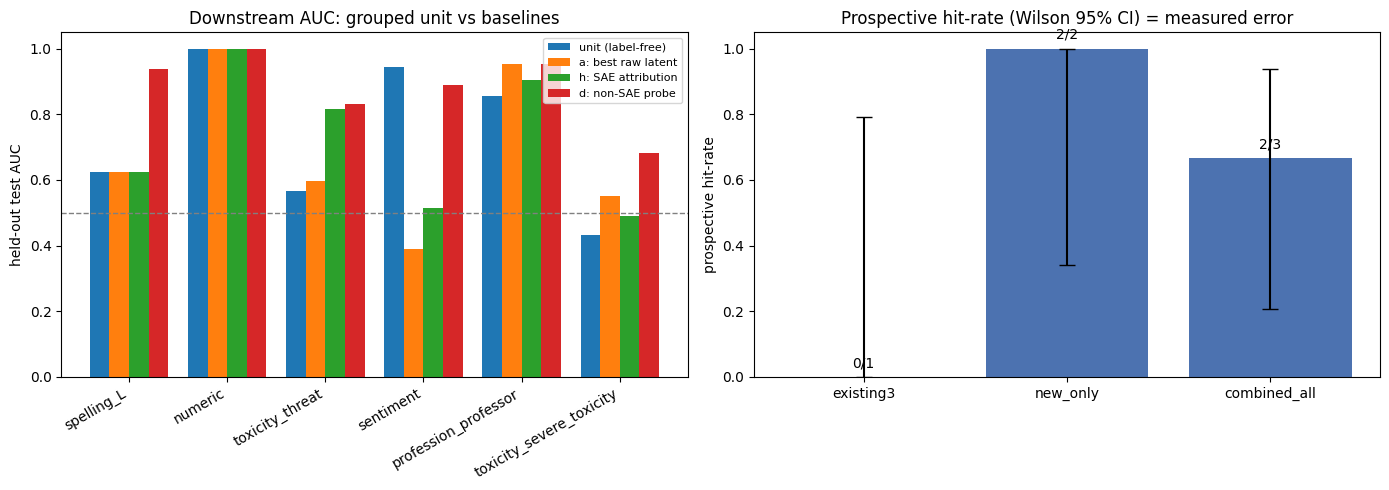


KEY OBSERVATION (smoke subset): on the absorption-regime concept 'sentiment' the label-free
grouped unit scores AUC=0.944 vs the best single raw SAE latent AUC=0.389 -> grouping recovers a
concept the best individual latent misses (the absorption failure mode this method screens for).

Full-scale reference (from run logs): KEY VERIFIED full-scale firing-Jaccard reproduced in run logs (not in this smoke subset): spelling L/O/T/I/D=0.017/0.039/0.003/0.009/0.017 (absorption), numeric=0.285 w/ recall-hole=0.800 (absorption), toxicity~0.69 (co_firing); combined rule balanced-acc=1.0 at tau_J~0.30, tau_h~0.78.


In [11]:
# ---------- (1) router decision-card table ----------
def _f(x): return None if x is None else round(float(x), 3)
rows = []
for c in concepts:
    rows.append(dict(concept=c["concept"], role=c["role"],
                     jaccard=_f(c["jaccard_median"]), recall_hole=_f(c["recall_hole_max"]),
                     pred_paper=c["pred_paper_thresholds"], ground_truth=c["ground_truth_regime"],
                     auc_unit=_f(c["auc_unit"]), auc_a=_f(c["auc_a"]),
                     auc_h=_f(c["auc_h"]), auc_d=_f(c["auc_d"]), ccrg_helps=c["ccrg_helps"]))
df = pd.DataFrame(rows)
print("ROUTER DECISION CARDS")
print(df.to_string(index=False))

# ---------- (2) downstream AUC: label-free grouped unit vs supervised baselines ----------
labels = [c["concept"] for c in concepts]
series = {"unit (label-free)":   [c["auc_unit"] for c in concepts],
          "a: best raw latent":  [c["auc_a"]    for c in concepts],
          "h: SAE attribution":  [c["auc_h"]    for c in concepts],
          "d: non-SAE probe":    [c["auc_d"]    for c in concepts]}
x = np.arange(len(labels)); w = 0.2
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for i, (name, vals) in enumerate(series.items()):
    ax[0].bar(x + (i - 1.5) * w, vals, w, label=name)
ax[0].set_xticks(x); ax[0].set_xticklabels(labels, rotation=30, ha="right")
ax[0].set_ylabel("held-out test AUC"); ax[0].set_ylim(0, 1.05)
ax[0].axhline(0.5, ls="--", c="grey", lw=1)
ax[0].set_title("Downstream AUC: grouped unit vs baselines")
ax[0].legend(fontsize=8)

# ---------- (3) prospective hit-rate with Wilson CIs ----------
keys = ["existing3", "new_only", "combined_all"]
rate = [hr[k]["rate"] for k in keys]
lo = [hr[k]["rate"] - hr[k]["wilson_ci"][0] for k in keys]
hi = [hr[k]["wilson_ci"][1] - hr[k]["rate"] for k in keys]
ax[1].bar(keys, rate, color="#4C72B0")
ax[1].errorbar(keys, rate, yerr=[lo, hi], fmt="none", ecolor="black", capsize=6)
ax[1].set_ylim(0, 1.05); ax[1].set_ylabel("prospective hit-rate")
ax[1].set_title("Prospective hit-rate (Wilson 95% CI) = measured error")
for i, k in enumerate(keys):
    ax[1].text(i, rate[i] + 0.03, "%d/%d" % (hr[k]["hits"], hr[k]["n"]), ha="center")
plt.tight_layout(); plt.show()

# ---------- (4) headline takeaway ----------
s_unit = next(c["auc_unit"] for c in concepts if c["concept"] == "sentiment")
s_a    = next(c["auc_a"]    for c in concepts if c["concept"] == "sentiment")
print("\nKEY OBSERVATION (smoke subset): on the absorption-regime concept 'sentiment' the label-free")
print("grouped unit scores AUC=%.3f vs the best single raw SAE latent AUC=%.3f -> grouping recovers a"
      % (s_unit, s_a))
print("concept the best individual latent misses (the absorption failure mode this method screens for).")
print("\nFull-scale reference (from run logs):", meta["full_scale_reference"])